# 🦍 Notebook 02 — SQL Queries & Exploratory Data Analysis
We use Python's built-in `sqlite3` to load all CSVs into an in-memory database,
then write SQL queries to JOIN, filter, and aggregate — exactly as you would with
a real ecological field database.

**Key SQL tasks:**
1. JOIN individuals ↔ groups ↔ rainfall into one analytical table
2. Compute group-level survival summaries
3. Filter by demographic subgroups (age class, sex)
4. Aggregate behavioural data per individual-year


## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
DATA_DIR = os.path.join('..', 'data')
print("✅ Libraries loaded")


✅ Libraries loaded


## Cell 2 — Load CSVs into SQLite (In-Memory Database)

In [2]:
# Create in-memory SQLite database
conn = sqlite3.connect(':memory:')   # ':memory:' → no file created on disk
cursor = conn.cursor()

# Load each CSV as a table
tables = {
    'rainfall'    : 'rainfall_monthly.csv',
    'gorilla_grps': 'gorilla_groups.csv',
    'individuals' : 'gorilla_individuals.csv',
    'observations': 'gorilla_observations.csv',
}

for table_name, filename in tables.items():
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    df.to_sql(table_name, conn, index=False, if_exists='replace')
    n_rows = cursor.execute(f'SELECT COUNT(*) FROM {table_name}').fetchone()[0]
    print(f"  ✅ Table '{table_name:<15}' → {n_rows:>6} rows")

print("\n✅ All tables loaded into SQLite.")


  ✅ Table 'rainfall       ' →    168 rows
  ✅ Table 'gorilla_grps   ' →    168 rows
  ✅ Table 'individuals    ' →   4080 rows
  ✅ Table 'observations   ' →  11008 rows

✅ All tables loaded into SQLite.


## Cell 3 — List Tables & Inspect Schema

In [3]:
# List all tables
tables_in_db = cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()
print("Tables in DB:", [t[0] for t in tables_in_db])

# Schema of main table
print("\n── Schema: individuals ──────────────────────────────────────────")
for col in cursor.execute("PRAGMA table_info(individuals)").fetchall():
    print(f"  {col[1]:<30} {col[2]}")


Tables in DB: ['rainfall', 'gorilla_grps', 'individuals', 'observations']

── Schema: individuals ──────────────────────────────────────────
  individual_id                  INTEGER
  group_id                       INTEGER
  group_name                     TEXT
  year                           INTEGER
  age                            INTEGER
  sex                            TEXT
  dominance_rank                 INTEGER
  forage_pct                     REAL
  rest_pct                       REAL
  social_pct                     REAL
  travel_pct                     REAL
  body_condition_score           REAL
  group_size                     INTEGER
  n_silverbacks                  INTEGER
  multi_male_group               INTEGER
  habitat_quality                REAL
  survived_next_year             INTEGER
  annual_rainfall_mm             REAL
  lagged_rainfall_mm             REAL


## Cell 4 — SQL Query 1: JOIN Individuals + Groups + Rainfall
This is the **primary analytical join** — assembles all predictors and the target variable into one flat table.


In [4]:
QUERY_FULL_JOIN = '''
SELECT
    i.individual_id,
    i.group_id,
    i.group_name,
    i.year,
    i.age,
    i.sex,
    i.dominance_rank,
    i.forage_pct,
    i.rest_pct,
    i.social_pct,
    i.travel_pct,
    i.body_condition_score,
    i.survived_next_year,

    -- Group-level variables (from gorilla_grps)
    g.group_size,
    g.n_silverbacks,
    g.n_blackbacks,
    g.n_adult_females,
    g.n_juveniles,
    g.n_infants,
    g.multi_male_group,
    g.habitat_quality_score,

    -- Environmental (from rainfall)
    r.annual_rainfall_mm,

    -- Lagged rainfall (prior year food availability)
    r_lag.annual_rainfall_mm  AS lagged_rainfall_mm

FROM individuals i
LEFT JOIN gorilla_grps g
    ON i.group_id = g.group_id AND i.year = g.year
LEFT JOIN (
    SELECT year, SUM(monthly_rainfall_mm) AS annual_rainfall_mm
    FROM rainfall GROUP BY year
) r ON i.year = r.year
LEFT JOIN (
    SELECT year, SUM(monthly_rainfall_mm) AS annual_rainfall_mm
    FROM rainfall GROUP BY year
) r_lag ON i.year - 1 = r_lag.year
WHERE i.age >= 0
ORDER BY i.group_name, i.individual_id, i.year
'''

analytical_df = pd.read_sql_query(QUERY_FULL_JOIN, conn)
print(f"Analytical dataset shape: {analytical_df.shape}")
display(analytical_df.head(5))

# Save for next notebooks
analytical_df.to_csv(os.path.join(DATA_DIR, 'analytical_dataset.csv'), index=False)
print("\n✅ Saved: analytical_dataset.csv")


Analytical dataset shape: (4080, 23)


,individual_id,group_id,group_name,year,age,sex,dominance_rank,forage_pct,rest_pct,social_pct,travel_pct,body_condition_score,survived_next_year,group_size,n_silverbacks,n_blackbacks,n_adult_females,n_juveniles,n_infants,multi_male_group,habitat_quality_score,annual_rainfall_mm,lagged_rainfall_mm
0,278,7,Agashya,2010,20,F,2,49.9,29.5,13.7,6.9,3.29,1,8,2,0,3,2,1,1,4.46,1133.2,NaN
1,278,7,Agashya,2011,21,F,1,40.6,35.0,7.5,16.9,2.89,1,8,2,0,3,2,1,1,4.46,969.9,1133.2
2,278,7,Agashya,2012,22,F,1,47.2,37.6,15.1,0.1,2.95,1,6,2,0,2,1,1,1,4.46,1035.6,969.9
3,278,7,Agashya,2013,23,F,2,47.3,25.7,12.7,14.3,3.71,1,7,2,1,3,0,1,1,4.46,1019.0,1035.6
4,278,7,Agashya,2014,24,F,1,29.3,26.0,14.8,29.9,3.53,1,5,2,0,2,1,0,1,4.46,1061.7,1019.0



✅ Saved: analytical_dataset.csv


## Cell 5 — SQL Query 2: Group-Level Survival Summary

In [5]:
QUERY_GROUP_SURV = '''
SELECT
    group_name,
    year,
    group_size,
    COUNT(individual_id)                   AS n_individuals,
    SUM(survived_next_year)                AS n_survived,
    ROUND(AVG(survived_next_year) * 100, 1) AS survival_rate_pct,
    ROUND(AVG(age), 1)                     AS mean_age,
    ROUND(AVG(body_condition_score), 2)    AS mean_body_cond
FROM individuals
GROUP BY group_name, year
ORDER BY survival_rate_pct ASC
'''

group_surv = pd.read_sql_query(QUERY_GROUP_SURV, conn)
print("── Group-level survival summary (worst 10 group-years) ─────────────")
display(group_surv.head(10))


── Group-level survival summary (worst 10 group-years) ─────────────


,group_name,year,group_size,n_individuals,n_survived,survival_rate_pct,mean_age,mean_body_cond
0,Agashya,2012,6,10,8,80.0,10.6,3.31
1,Agashya,2014,5,10,8,80.0,12.0,3.13
2,Bwenge,2011,7,5,4,80.0,13.4,3.08
3,Amahoro,2010,11,11,9,81.8,13.0,2.80
4,Bwenge,2014,6,6,5,83.3,10.0,2.66
5,Bwenge,2018,6,7,6,85.7,11.6,2.77
6,Ugenda,2023,6,22,19,86.4,7.2,3.06
7,Ugenda,2020,11,15,13,86.7,7.5,3.29
8,Ugenda,2015,10,8,7,87.5,8.4,2.99
9,Amahoro,2022,3,9,8,88.9,21.2,3.11


## Cell 6 — SQL Query 3: Survival by Sex & Age Class

In [6]:
QUERY_DEMO = '''
SELECT
    sex,
    CASE
        WHEN age < 3  THEN '0_Infant'
        WHEN age < 8  THEN '1_Juvenile'
        WHEN age < 12 THEN '2_Subadult'
        WHEN age < 20 THEN '3_Prime_Adult'
        ELSE               '4_Senior'
    END AS age_class,
    COUNT(*)                                AS n,
    ROUND(AVG(survived_next_year)*100, 2)   AS survival_pct,
    ROUND(AVG(body_condition_score), 2)     AS mean_body_cond,
    ROUND(AVG(dominance_rank), 2)           AS mean_dom_rank
FROM individuals
GROUP BY sex, age_class
ORDER BY sex, age_class
'''

demo_surv = pd.read_sql_query(QUERY_DEMO, conn)
print("── Survival by sex and age class ───────────────────────────────────")
display(demo_surv)


── Survival by sex and age class ───────────────────────────────────


,sex,age_class,n,survival_pct,mean_body_cond,mean_dom_rank
0,F,0_Infant,424,94.34,3.19,3.98
1,F,1_Juvenile,628,100.00,3.17,3.91
2,F,2_Subadult,371,100.00,3.17,4.00
3,F,3_Prime_Adult,484,100.00,3.23,3.72
4,F,4_Senior,359,98.33,3.19,3.54
5,M,0_Infant,455,91.87,3.18,4.99
6,M,1_Juvenile,524,100.00,3.23,5.04
7,M,2_Subadult,290,100.00,3.09,5.04
8,M,3_Prime_Adult,268,100.00,3.19,1.40
9,M,4_Senior,277,97.83,3.21,1.30


## Cell 7 — SQL Query 4: Aggregated Behavioural Data per Individual-Year

In [7]:
QUERY_OBS = '''
SELECT
    o.individual_id,
    o.year,
    COUNT(o.obs_id)                       AS n_obs_sessions,
    ROUND(AVG(o.foraging_rate_pct), 2)    AS mean_foraging_pct,
    ROUND(AVG(o.agonistic_events), 2)     AS mean_agonistic,
    ROUND(AVG(o.affiliation_events), 2)   AS mean_affiliation,
    ROUND(AVG(o.nearest_neighbour_dist_m), 2) AS mean_nn_dist_m,
    SUM(CASE WHEN o.season='wet' THEN 1 ELSE 0 END) AS n_wet_sessions,
    SUM(CASE WHEN o.season='dry' THEN 1 ELSE 0 END) AS n_dry_sessions
FROM observations o
GROUP BY o.individual_id, o.year
'''

obs_agg = pd.read_sql_query(QUERY_OBS, conn)
print(f"Aggregated observation sessions: {obs_agg.shape}")
display(obs_agg.head(5))

# Merge into analytical dataset
analytical_df = analytical_df.merge(obs_agg, on=['individual_id','year'], how='left')
print(f"\nAnalytical dataset with obs features: {analytical_df.shape}")
analytical_df.to_csv(os.path.join(DATA_DIR, 'analytical_dataset.csv'), index=False)
print("✅ Saved updated: analytical_dataset.csv")


Aggregated observation sessions: (2448, 9)


,individual_id,year,n_obs_sessions,mean_foraging_pct,mean_agonistic,mean_affiliation,mean_nn_dist_m,n_wet_sessions,n_dry_sessions
0,1,2010,3,44.47,2.33,0.33,10.53,1,2
1,1,2014,3,50.20,1.33,1.33,12.07,2,1
2,1,2015,6,54.03,1.33,1.00,7.32,3,3
3,1,2016,6,37.20,2.67,1.67,11.30,2,4
4,1,2018,3,52.43,2.67,1.33,2.37,2,1



Analytical dataset with obs features: (4080, 30)
✅ Saved updated: analytical_dataset.csv


## Cell 8 — Missing Value Analysis

In [8]:
missing = analytical_df.isnull().sum()
missing_pct = (analytical_df.isnull().sum() / len(analytical_df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print("── Missing Values ──────────────────────────────────────────────────")
if missing_report.empty:
    print("  ✅ No missing values in core columns.")
else:
    display(missing_report)
    print("\n  NOTE: Observation-derived features (n_obs_sessions etc.) are NaN")
    print("  for individuals with no focal sessions — we'll impute in NB03.")


── Missing Values ──────────────────────────────────────────────────


,missing_count,missing_pct
n_obs_sessions,1632,40.0
mean_foraging_pct,1632,40.0
mean_agonistic,1632,40.0
mean_affiliation,1632,40.0
n_wet_sessions,1632,40.0
mean_nn_dist_m,1632,40.0
n_dry_sessions,1632,40.0
lagged_rainfall_mm,155,3.8



  NOTE: Observation-derived features (n_obs_sessions etc.) are NaN
  for individuals with no focal sessions — we'll impute in NB03.


## Cell 9 — Correlation Heatmap (Numerical Features)

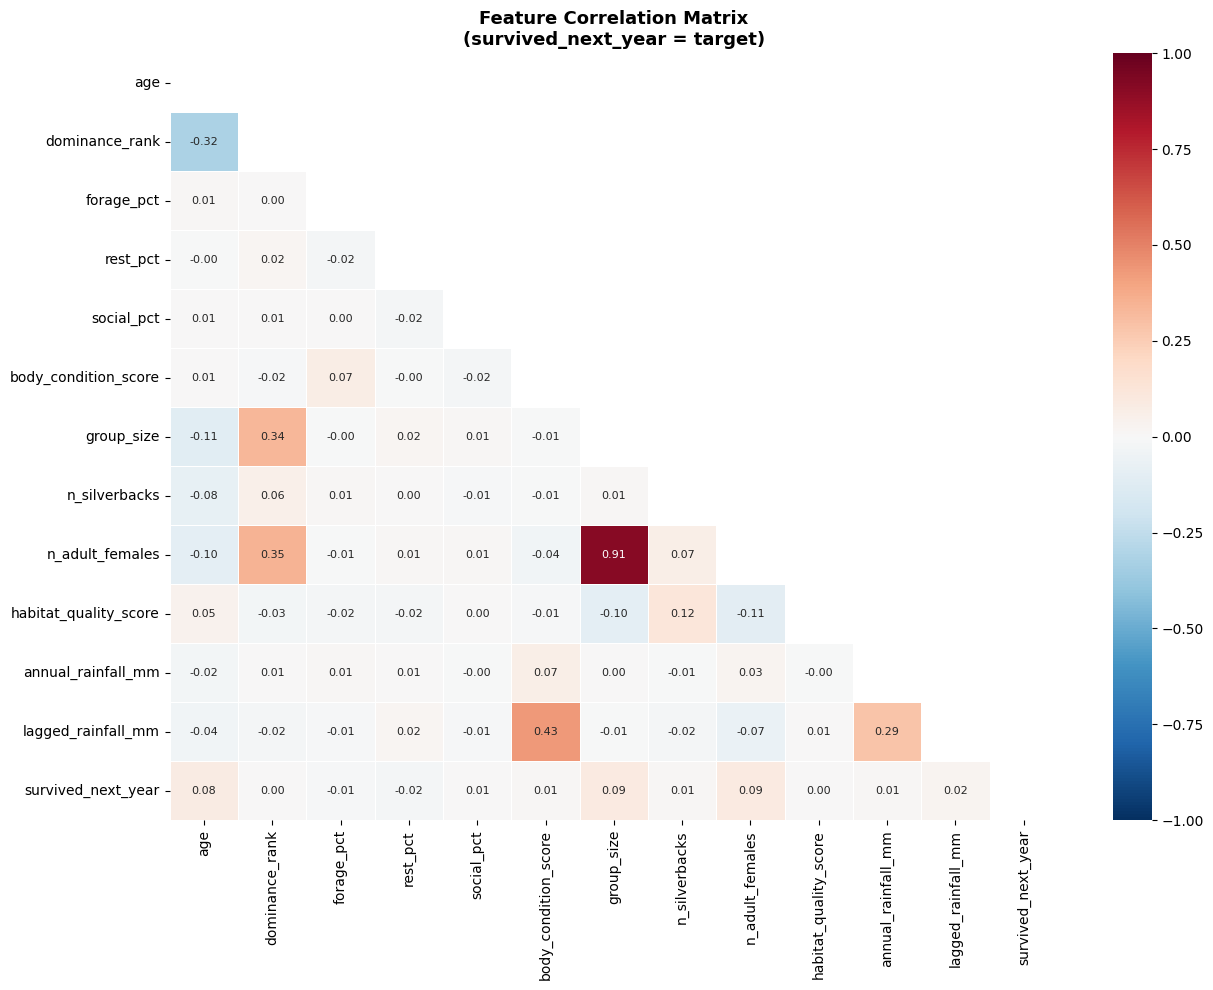


── Top correlations with survival ──────────────────────────────────
group_size              0.089606
n_adult_females         0.086534
age                     0.078575
lagged_rainfall_mm      0.024447
rest_pct               -0.021300
annual_rainfall_mm      0.013913
body_condition_score    0.013733
forage_pct             -0.012049
n_silverbacks           0.011180
social_pct              0.007809


In [9]:
num_cols = ['age','dominance_rank','forage_pct','rest_pct','social_pct',
            'body_condition_score','group_size','n_silverbacks','n_adult_females',
            'habitat_quality_score','annual_rainfall_mm','lagged_rainfall_mm',
            'survived_next_year']

corr = analytical_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix\n(survived_next_year = target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..','data','02_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr['survived_next_year'].drop('survived_next_year').sort_values(key=abs, ascending=False)
print("\n── Top correlations with survival ──────────────────────────────────")
print(target_corr.head(10).to_string())


## Cell 10 — Univariate EDA: Group Size vs. Survival

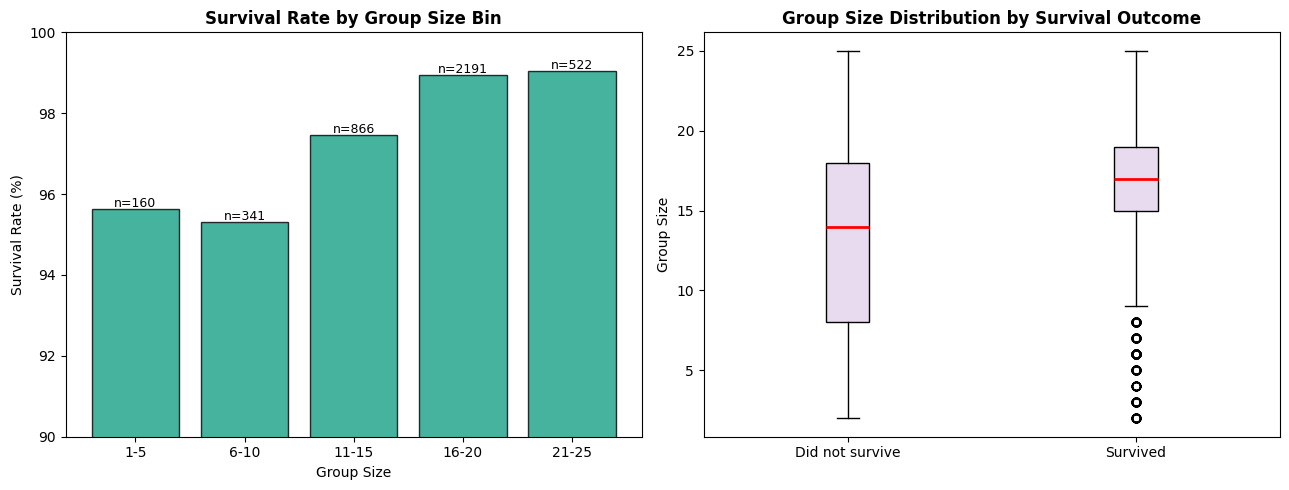


✅ Notebook 02 complete. Proceed to 03_feature_engineering.ipynb


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Survival rate binned by group size
bins = pd.cut(analytical_df['group_size'], bins=[0,5,10,15,20,25,40], labels=['1-5','6-10','11-15','16-20','21-25','26+'])
surv_by_gs = analytical_df.groupby(bins)['survived_next_year'].agg(['mean','count']).reset_index()
surv_by_gs.columns = ['group_size_bin','survival_rate','n']

axes[0].bar(surv_by_gs['group_size_bin'], surv_by_gs['survival_rate']*100,
            color='#16a085', edgecolor='black', alpha=0.8)
axes[0].set_title('Survival Rate by Group Size Bin', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Group Size')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(90, 100)
for i, row in surv_by_gs.iterrows():
    axes[0].text(i, row['survival_rate']*100 + 0.05, f"n={row['n']}", ha='center', fontsize=9)

# Boxplot: group size by survival outcome
surv_labels = analytical_df['survived_next_year'].map({0:'Did not survive', 1:'Survived'})
surv_0 = analytical_df[analytical_df['survived_next_year']==0]['group_size']
surv_1 = analytical_df[analytical_df['survived_next_year']==1]['group_size']
axes[1].boxplot([surv_0, surv_1], labels=['Did not survive','Survived'],
                patch_artist=True,
                boxprops=dict(facecolor='#e8daef', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Group Size Distribution by Survival Outcome', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Group Size')

plt.tight_layout()
plt.savefig(os.path.join('..','data','02_groupsize_survival.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Notebook 02 complete. Proceed to 03_feature_engineering.ipynb")
